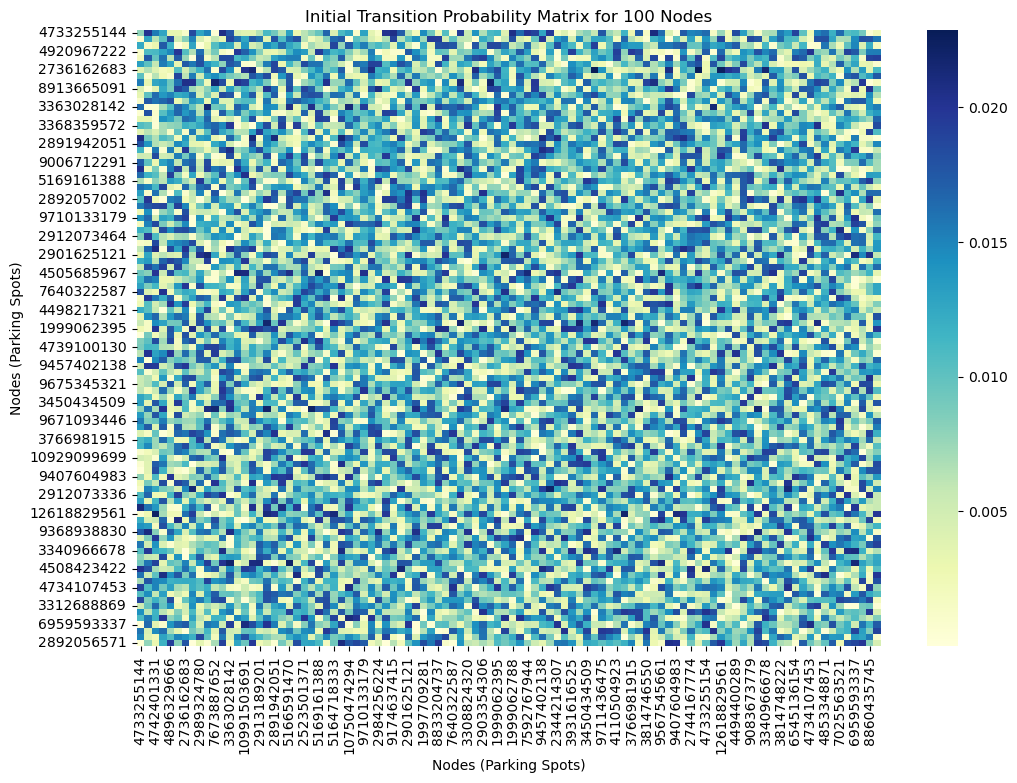

In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Generate City Network
place_name = "Nantong, China"
graph = ox.graph_from_place(place_name, network_type='bike')
graph = ox.project_graph(graph)  # Projected graph for accurate distance calculations

# Select 100 random nodes from the graph to act as parking spots
np.random.seed(42)
all_nodes = list(graph.nodes())
random_nodes = random.sample(all_nodes, 100)

# Generate Distance Matrix
# Calculate the shortest path length between each pair of nodes using network distance
distance_matrix = np.zeros((100, 100))
node_indices = {node: idx for idx, node in enumerate(random_nodes)}

for i, node1 in enumerate(random_nodes):
    for j, node2 in enumerate(random_nodes):
        if i != j:
            try:
                length = nx.shortest_path_length(graph, source=node1, target=node2, weight='length')
                distance_matrix[i, j] = length
            except nx.NetworkXNoPath:
                distance_matrix[i, j] = np.inf  # If there's no path between nodes

# Convert distance to time in minutes assuming average biking speed of 15 km/h (250 m/min)
distance_matrix = distance_matrix / 250

# Create Transition Probability Matrix
# For now, generate probabilities randomly; adjust later based on model
transition_matrix = np.random.rand(100, 100)
transition_matrix = transition_matrix / transition_matrix.sum(axis=1, keepdims=True)  # Normalize rows

# Convert to DataFrame for better visualization
transition_df = pd.DataFrame(transition_matrix, index=random_nodes, columns=random_nodes)

# Visualize the Transition Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(transition_df, cmap="YlGnBu")
plt.title("Initial Transition Probability Matrix for 100 Nodes")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()


In [2]:
transition_df.head()

,4733255144,9716259649,4742401331,4920967222,4896329666,12073844532,2736162683,6544700619,2989324780,8913665091,...,4734107453,9675345334,4853348871,3312688869,7025563521,2888030269,6959593337,5164788317,8860435745,2892056571
4733255144,0.007966,0.020220,0.015568,0.012733,0.003318,0.003318,0.001235,0.018422,0.012785,0.015060,...,0.002544,0.015170,0.016181,0.011937,0.016397,0.010502,0.011118,0.009093,0.000541,0.002295
9716259649,0.000631,0.012784,0.006315,0.010216,0.018230,0.005008,0.008243,0.015177,0.004596,0.001546,...,0.001870,0.018022,0.018087,0.012717,0.006810,0.007015,0.014582,0.018020,0.017819,0.015665
4742401331,0.012404,0.001626,0.003123,0.017360,0.011716,0.000178,0.001960,0.012819,0.000098,0.003107,...,0.000589,0.000722,0.015893,0.006959,0.002455,0.010090,0.014876,0.004170,0.012034,0.001649
4920967222,0.001052,0.010819,0.011008,0.012978,0.014784,0.019869,0.010512,0.006576,0.016190,0.005514,...,0.020167,0.008401,0.007574,0.015808,0.006939,0.018951,0.017478,0.008734,0.015288,0.015363
4896329666,0.001998,0.017490,0.009791,0.016015,0.006202,0.017354,0.007542,0.000210,0.017545,0.001769,...,0.008830,0.012017,0.005375,0.003645,0.008986,0.006847,0.011310,0.001506,0.018882,0.019111


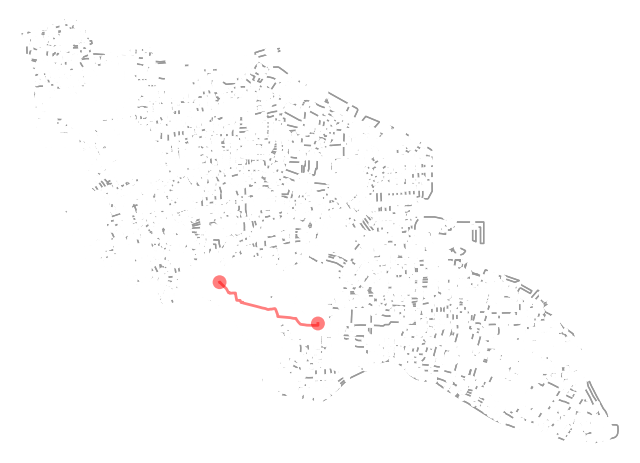

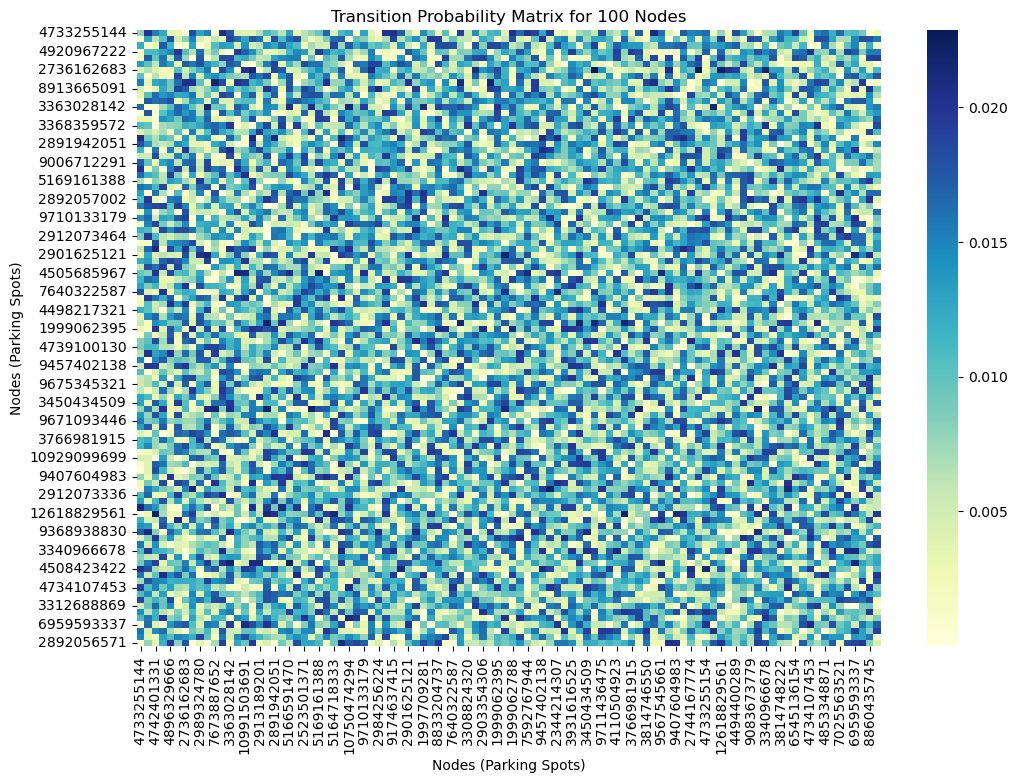

In [3]:
# Simulate Markov Chain
# Parameters for simulation
num_steps = 15  # Number of steps to simulate: 15 X 5 min = 75min
current_node = random.choice(random_nodes)  # Randomly choose a starting node
trajectory = [current_node]

for _ in range(num_steps):
    current_index = node_indices[current_node]
    next_node_index = np.random.choice(range(100), p=transition_matrix[current_index])
    current_node = random_nodes[next_node_index]
    trajectory.append(current_node)

# Visualize the Trajectory on the Graph
fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')

# Plot the nodes with trajectory highlighted
for i in range(1, len(trajectory)):
    node1 = trajectory[i - 1]
    node2 = trajectory[i]
    
    try:
        route = nx.shortest_path(graph, source=node1, target=node2, weight='length')
        ox.plot_graph_route(graph, route, route_color='red', route_linewidth=2, ax=ax, close=False)
    except nx.NetworkXNoPath:
        continue

# Visualize Transition Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(transition_df, cmap="YlGnBu")
plt.title("Transition Probability Matrix for 100 Nodes")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()

## Add factors that impacts transition matrix

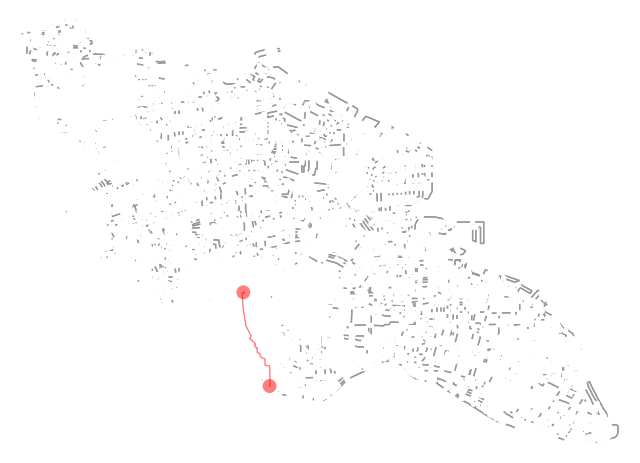

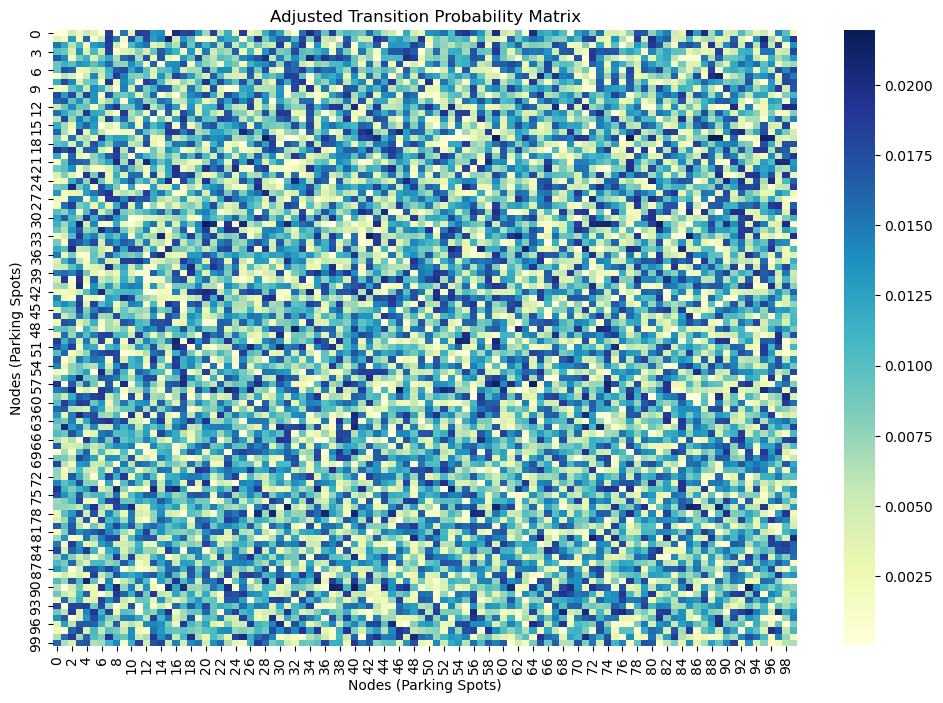

In [4]:
# Define Time-of-Day and Seasonal Factors
time_of_day_factors = {
    "early_morning": 0.5,   # Low demand (e.g., 12 AM - 6 AM)
    "morning_peak": 1.5,    # High demand (e.g., 7 AM - 10 AM)
    "midday": 1.0,          # Baseline (e.g., 11 AM - 4 PM)
    "evening_peak": 1.3,    # High demand (e.g., 5 PM - 8 PM)
    "night": 0.6            # Reduced usage (e.g., 9 PM - 11 PM)
}

seasonal_factors = {
    "winter": 0.7,
    "spring": 1.0,
    "summer": 1.2,
    "autumn": 0.9
}



# Example season for simulation
season = "summer"
season_factor = seasonal_factors[season]

# Generate Base Transition Probability Matrix
base_transition_matrix = np.random.rand(100, 100)
base_transition_matrix = base_transition_matrix / base_transition_matrix.sum(axis=1, keepdims=True)

# Function to adjust transition probabilities based on time of day
def adjust_transition_matrix(matrix, time_factor, season_factor):
    adjusted_matrix = matrix * time_factor * season_factor
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    return adjusted_matrix

# Simulate Markov Chain
num_steps = 288  # One day = 288 steps (5-minute intervals)

# Define time periods over the day
time_periods = {
    (0, 71): "early_morning",   # 12 AM - 6 AM
    (72, 119): "morning_peak",   # 7 AM - 10 AM
    (120, 239): "midday",        # 11 AM - 4 PM
    (240, 287): "evening_peak"   # 5 PM - 8 PM
}

# Initialize simulation variables
current_node = random.choice(random_nodes)
trajectory = [current_node]
transition_matrix = base_transition_matrix.copy()

for step in range(num_steps):
    # Determine the time of day for the current step
    for (start, end), period in time_periods.items():
        if start <= step <= end:
            time_factor = time_of_day_factors[period]
            break
    else:
        time_factor = time_of_day_factors["night"]  # Default to night if not in other ranges

    # Adjust the transition matrix based on time of day and season
    adjusted_matrix = adjust_transition_matrix(transition_matrix, time_factor, season_factor)
    
    current_index = node_indices[current_node]
    next_node_index = np.random.choice(range(100), p=adjusted_matrix[current_index])
    current_node = random_nodes[next_node_index]
    trajectory.append(current_node)

# Step 5: Visualize the Simulation Trajectory
fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')

# Plot the nodes with trajectory highlighted
for i in range(1, len(trajectory)):
    node1 = trajectory[i - 1]
    node2 = trajectory[i]
    
    try:
        route = nx.shortest_path(graph, source=node1, target=node2, weight='length')
        ox.plot_graph_route(graph, route, route_color='red', route_linewidth=1, ax=ax, close=False)
    except nx.NetworkXNoPath:
        continue


# Step 6: Visualize Transition Matrix Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pd.DataFrame(adjusted_matrix), cmap="YlGnBu")
plt.title("Adjusted Transition Probability Matrix")
plt.xlabel("Nodes (Parking Spots)")
plt.ylabel("Nodes (Parking Spots)")
plt.show()

In [22]:
import os

In [23]:
# Define Factors
time_of_day_factors = {
    "early_morning": 0.5,
    "morning_peak": 1.5,
    "midday": 1.0,
    "evening_peak": 1.3,
    "night": 0.6
}

seasonal_factors = {
    "winter": 0.7,
    "spring": 1.0,
    "summer": 1.2,
    "autumn": 0.9
}

time_periods = {
    (0, 71): "early_morning",   # 12 AM - 6 AM
    (72, 119): "morning_peak",   # 7 AM - 10 AM
    (120, 239): "midday",        # 11 AM - 4 PM
    (240, 287): "evening_peak"   # 5 PM - 8 PM
}

# Generate City Network
def generate_city_network(place_name="Nantong, China", num_nodes=100):
    graph = ox.graph_from_place(place_name, network_type='bike')
    graph = ox.project_graph(graph)
    all_nodes = list(graph.nodes())
    random_nodes = random.sample(all_nodes, num_nodes)
    node_indices = {node: idx for idx, node in enumerate(random_nodes)}
    return graph, random_nodes, node_indices

# Generate Base Transition Matrix
def generate_transition_matrix(size=100):
    matrix = np.random.rand(size, size)
    matrix = matrix / matrix.sum(axis=1, keepdims=True)
    return matrix

# Adjust Transition Matrix with Factors
def adjust_transition_matrix(matrix, time_factor, season_factor):
    adjusted_matrix = matrix * time_factor * season_factor
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    return adjusted_matrix

# Run Single Simulation
def run_simulation(graph, random_nodes, node_indices, transition_matrix, num_steps=288, season='summer'):
    season_factor = seasonal_factors[season]
    current_node = random.choice(random_nodes)
    trajectory = [current_node]

    for step in range(num_steps):
        for (start, end), period in time_periods.items():
            if start <= step <= end:
                time_factor = time_of_day_factors[period]
                break
        else:
            time_factor = time_of_day_factors["night"]

        adjusted_matrix = adjust_transition_matrix(transition_matrix, time_factor, season_factor)
        
        current_index = node_indices[current_node]
        next_node_index = np.random.choice(range(100), p=adjusted_matrix[current_index])
        current_node = random_nodes[next_node_index]
        trajectory.append(current_node)

    return trajectory, adjusted_matrix

# Run Batch Simulations
def run_batch_simulations(graph, random_nodes, node_indices, scenarios, num_steps=288, save_path="simulation_results"):
    results = {}
    
    # Ensure the save path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    for season, time_period in scenarios:
        transition_matrix = generate_transition_matrix()
        trajectory, final_matrix = run_simulation(graph, random_nodes, node_indices, transition_matrix, num_steps, season)
        
        results[(season, time_period)] = {
            'trajectory': trajectory,
            'transition_matrix': final_matrix
        }
        
        # Save the trajectory and transition matrix to CSV files
        pd.DataFrame(trajectory, columns=['Node']).to_csv(f'{save_path}/trajectory_{season}_{time_period}.csv', index=False)
        pd.DataFrame(final_matrix).to_csv(f'{save_path}/transition_matrix_{season}_{time_period}.csv', index=False)
    
    return results

# Visualize Heatmap of Transition Matrix
def visualize_transition_matrix(transition_matrix, title="Transition Probability Matrix"):
    plt.figure(figsize=(12, 8))
    sns.heatmap(pd.DataFrame(transition_matrix), cmap="YlGnBu")
    plt.title(title)
    plt.xlabel("Nodes (Parking Spots)")
    plt.ylabel("Nodes (Parking Spots)")
    plt.show()

# Visualize Simulation Trajectory
def visualize_trajectory(graph, trajectory, title="Simulated Bike Trajectory"):
    fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')
    
    for i in range(1, len(trajectory)):
        node1 = trajectory[i - 1]
        node2 = trajectory[i]
        
        try:
            route = nx.shortest_path(graph, source=node1, target=node2, weight='length')
            ox.plot_graph_route(graph, route, route_color='red', route_linewidth=1, ax=ax, close=False)
        except nx.NetworkXNoPath:
            continue
    
    plt.title(title)
    plt.show()

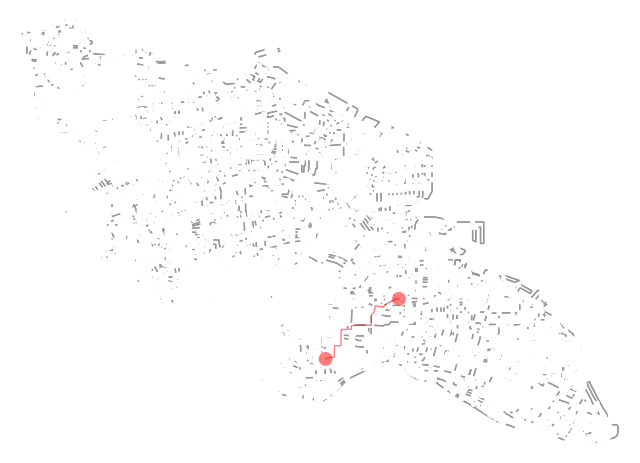

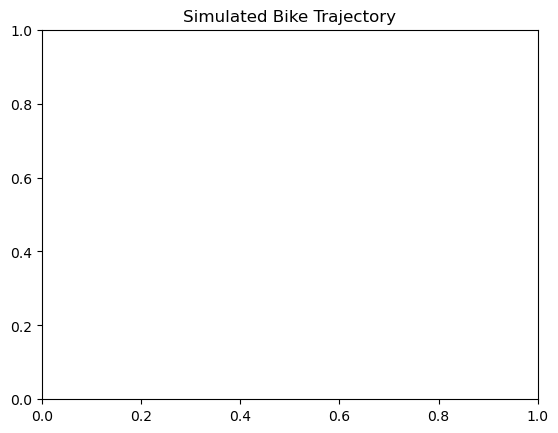

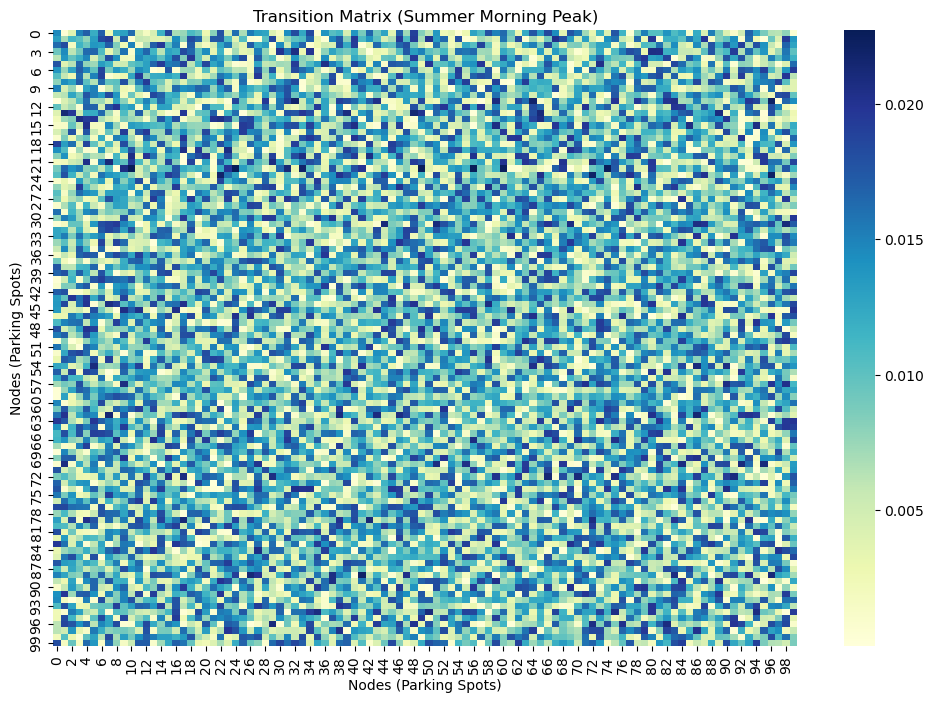

In [24]:
# Generate the city network
graph, random_nodes, node_indices = generate_city_network()

# Define scenarios to simulate
scenarios = [
    ('summer', 'morning_peak'),
    ('summer', 'midday'),
    ('summer', 'evening_peak'),
    ('winter', 'morning_peak'),
    ('winter', 'midday'),
    ('winter', 'evening_peak'),
    ('spring', 'morning_peak'),
    ('autumn', 'midday')
]

# Run batch simulations
simulation_results = run_batch_simulations(graph, random_nodes, node_indices, scenarios)

# Visualize one of the simulations
# visualize_trajectory(graph, simulation_results[('summer', 'morning_peak')]['trajectory'])
visualize_transition_matrix(simulation_results[('summer', 'morning_peak')]['transition_matrix'], title="Transition Matrix (Summer Morning Peak)")

## Change In Transition Matrix

In [19]:
from scipy.special import rel_entr

def generate_adjusted_transition_matrix(distance_matrix, kl_threshold=0.5):
    # Step 1: Create inverse-distance matrix
    inv_distances = 1 / (distance_matrix + 1e-6)
    np.fill_diagonal(inv_distances, 0)

    row_sums = inv_distances.sum(axis=1, keepdims=True)
    # Avoid division by zero
    inv_prob_matrix = np.divide(
        inv_distances,
        row_sums,
        out=np.zeros_like(inv_distances),  # fallback if divide-by-zero
        where=row_sums != 0
    )

    # Replace zero-probability rows with uniform distribution (optional fallback)
    for i in range(inv_prob_matrix.shape[0]):
        if inv_prob_matrix[i].sum() == 0:
            inv_prob_matrix[i] = np.ones(inv_prob_matrix.shape[1]) / inv_prob_matrix.shape[1]

    # Generate initial random transition matrix
    random_matrix = np.random.rand(distance_matrix.shape[0], distance_matrix.shape[1])
    random_matrix = random_matrix / random_matrix.sum(axis=1, keepdims=True)

    # Compute KL divergence row-wise and blend
    kl_divs = np.sum(rel_entr(random_matrix, inv_prob_matrix), axis=1)

    adjusted_matrix = np.copy(random_matrix)
    for i in range(len(kl_divs)):
        if kl_divs[i] > kl_threshold:
            adjusted_matrix[i] = inv_prob_matrix[i]

    # Normalize again for numerical safety
    adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)
    return adjusted_matrix

## Adjuested Batch Simulation

In [47]:
def generate_mock_environmental_data(num_nodes=100, season="summer", time_period="morning_peak"):
    """
    Create synthetic environmental features including seasonal factor, time factor, and location type.
    """
    # Season effects (baseline demand multiplier)
    season_factor = {
        "winter": 0.7,
        "spring": 1.0,
        "summer": 1.2,
        "autumn": 0.9
    }

    # Time-of-day effect
    time_of_day_factor = {
        "early_morning": 0.5,
        "morning_peak": 1.5,
        "midday": 1.0,
        "evening_peak": 1.3,
        "night": 0.6
    }

    # Randomly assign location type: business, college, subway, residential
    location_types = np.random.choice(["business", "college", "subway", "residential"], size=num_nodes)
    location_factor_map = {
        "business": 1.5,
        "college": 1.3,
        "subway": 1.4,
        "residential": 1.0
    }
    location_factors = np.array([location_factor_map[loc] for loc in location_types])

    # Assemble features
    seasonal = np.full(num_nodes, season_factor[season])
    time_of_day = np.full(num_nodes, time_of_day_factor[time_period])
    location = location_factors

    # Combine into design matrix
    X = np.column_stack([seasonal, time_of_day, location])
    return X

# Updated node demand prediction using new features
def predict_node_demand(season, time_period, num_nodes=100):
    X = generate_mock_environmental_data(num_nodes=num_nodes, season=season, time_period=time_period)
    beta = np.array([1.0, 1.2, 1.5])  # weights for season, time, location type
    y_pred = X @ beta + np.random.randn(num_nodes) * 0.2  # small noise
    y_pred = np.maximum(y_pred, 0.1)
    demand_normalized = y_pred / y_pred.sum()
    return demand_normalized

In [48]:
import os

# Run Batch Simulations
def run_batch_simulations(graph, random_nodes, node_indices, distance_matrix, scenarios,
                          num_steps=288, save_path="simulation_results", kl_threshold=0.5):
    import os
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    results = {}

    for season, time_period in scenarios:
        # 1. Generate distance-aware transition matrix
        base_adjusted_matrix = generate_adjusted_transition_matrix(distance_matrix, kl_threshold)

        # 2. Predict demand based on season, time, and location type
        demand_vector = predict_node_demand(season, time_period, num_nodes=len(random_nodes))

        # 3. Adjust transition matrix by scaling with demand vector
        adjusted_matrix = base_adjusted_matrix * demand_vector[np.newaxis, :]  # scale columns
        adjusted_matrix = adjusted_matrix / adjusted_matrix.sum(axis=1, keepdims=True)

        # 4. Simulate e-bike trajectory
        current_node = random.choice(random_nodes)
        trajectory = [current_node]

        for step in range(num_steps):
            current_index = node_indices[current_node]
            next_node_index = np.random.choice(range(len(random_nodes)), p=adjusted_matrix[current_index])
            current_node = random_nodes[next_node_index]
            trajectory.append(current_node)

        # 5. Save results
        results[(season, time_period)] = {
            'trajectory': trajectory,
            'transition_matrix': adjusted_matrix
        }

        # Save CSVs
        pd.DataFrame(trajectory, columns=["Node"]).to_csv(f"{save_path}/trajectory_{season}_{time_period}.csv", index=False)
        pd.DataFrame(adjusted_matrix).to_csv(f"{save_path}/transition_matrix_{season}_{time_period}.csv", index=False)

    return results

In [51]:
# Define combinations of seasons and time periods
scenarios = [
    ('summer', 'morning_peak'),
    ('summer', 'midday'),
    ('summer', 'evening_peak'),
    ('winter', 'morning_peak'),
    ('winter', 'midday'),
    ('winter', 'evening_peak'),
    ('spring', 'morning_peak'),
    ('autumn', 'midday')
]

# Run all simulations
simulation_results = run_batch_simulations(
    graph=graph,
    random_nodes=random_nodes,
    node_indices=node_indices,
    distance_matrix=distance_matrix,
    scenarios=scenarios,
    num_steps=288,
    save_path="simulation_results2",
    kl_threshold=0.5
)

In [54]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

def visualize_trajectory(graph, trajectory):
    # Step 1: Plot the base graph and retrieve ax
    fig, ax = ox.plot_graph(graph, show=False, close=False, bgcolor='white')

    # Step 2: Overlay each trajectory segment as a route
    for i in range(1, len(trajectory)):
        node1 = trajectory[i - 1]
        node2 = trajectory[i]
        try:
            route = nx.shortest_path(graph, node1, node2, weight='length')
            ox.plot_graph_route(graph, route, ax=ax, route_color='red', route_linewidth=2, close=False, show=False)
        except nx.NetworkXNoPath:
            continue

    # Step 3: Use matplotlib directly to show the figure
    fig.suptitle("Simulated E-bike Trajectory (Markov Chain)", fontsize=14)
    plt.show()


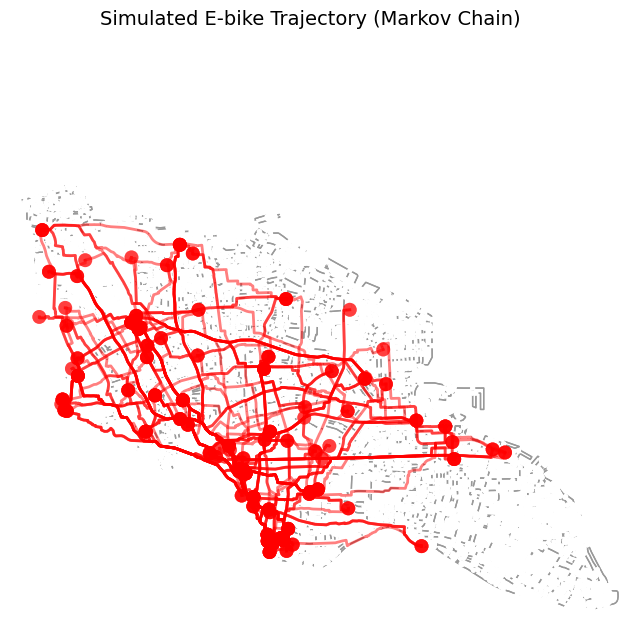

In [55]:
visualize_trajectory(graph, simulation_results[('summer', 'morning_peak')]['trajectory'])